In [126]:
import numpy as np
import pyrepseq as prs
import matplotlib.pyplot as plt

from functools import partial

import repertoire_simulator.lib as lib

plt.style.use("../project_style.mplstyle")
%config InlineBackend.figure_format = 'retina'

DATA_PATH = "../data/"

In [127]:
c = np.load(DATA_PATH + "sim_results/simple_sim.npz")["clonal_abundances"]

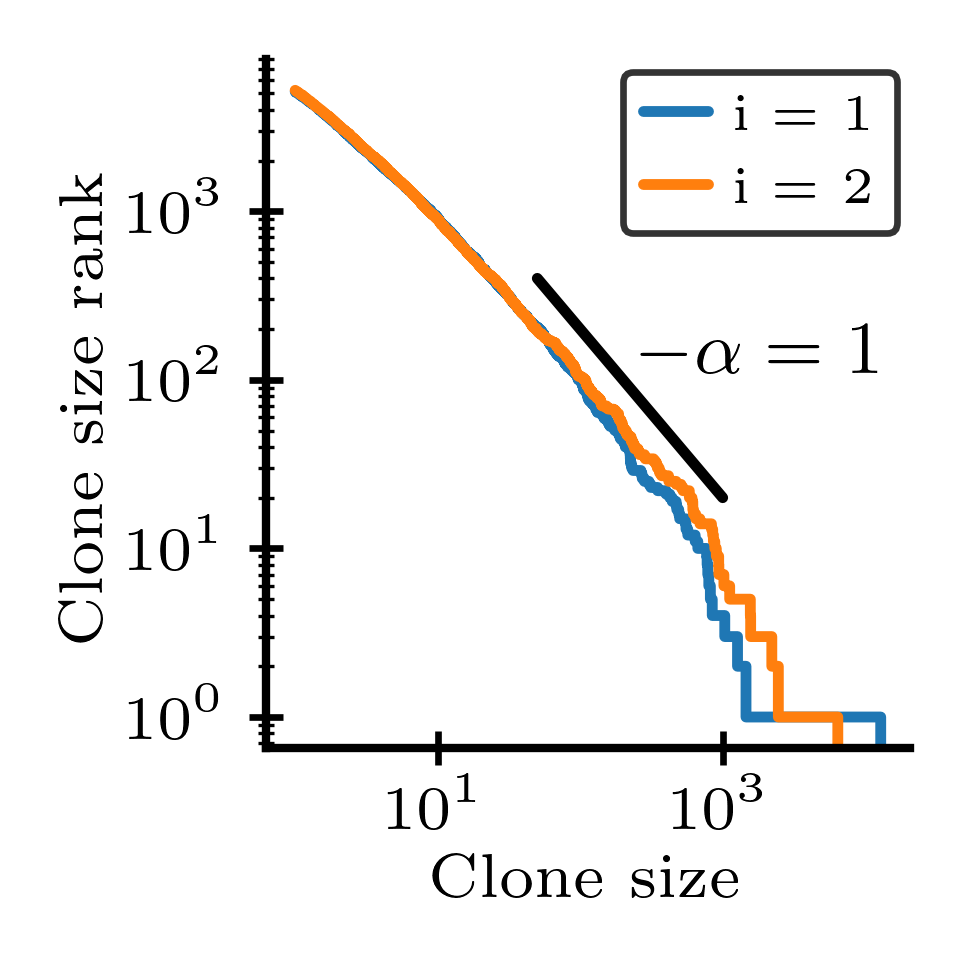

In [134]:
fig, ax = plt.subplots(figsize=(1.5, 1.5), layout='constrained')
lib.plot_referencescaling(ax=ax, x=[5e1, 1e3], factor=2e4, exponent=-1)
for i in range(c.shape[1]):
    prs.plotting.rankfrequency(c[:, i][c[:, i] >= 1], ax=ax, normalize_x=False, label=f'i = {i+1}')
ax.legend();

## Trajectories

In [129]:
records = np.load(DATA_PATH + "sim_results/simple_sim_record.npz", allow_pickle=True)
t = records['t']
c_t = records['c']

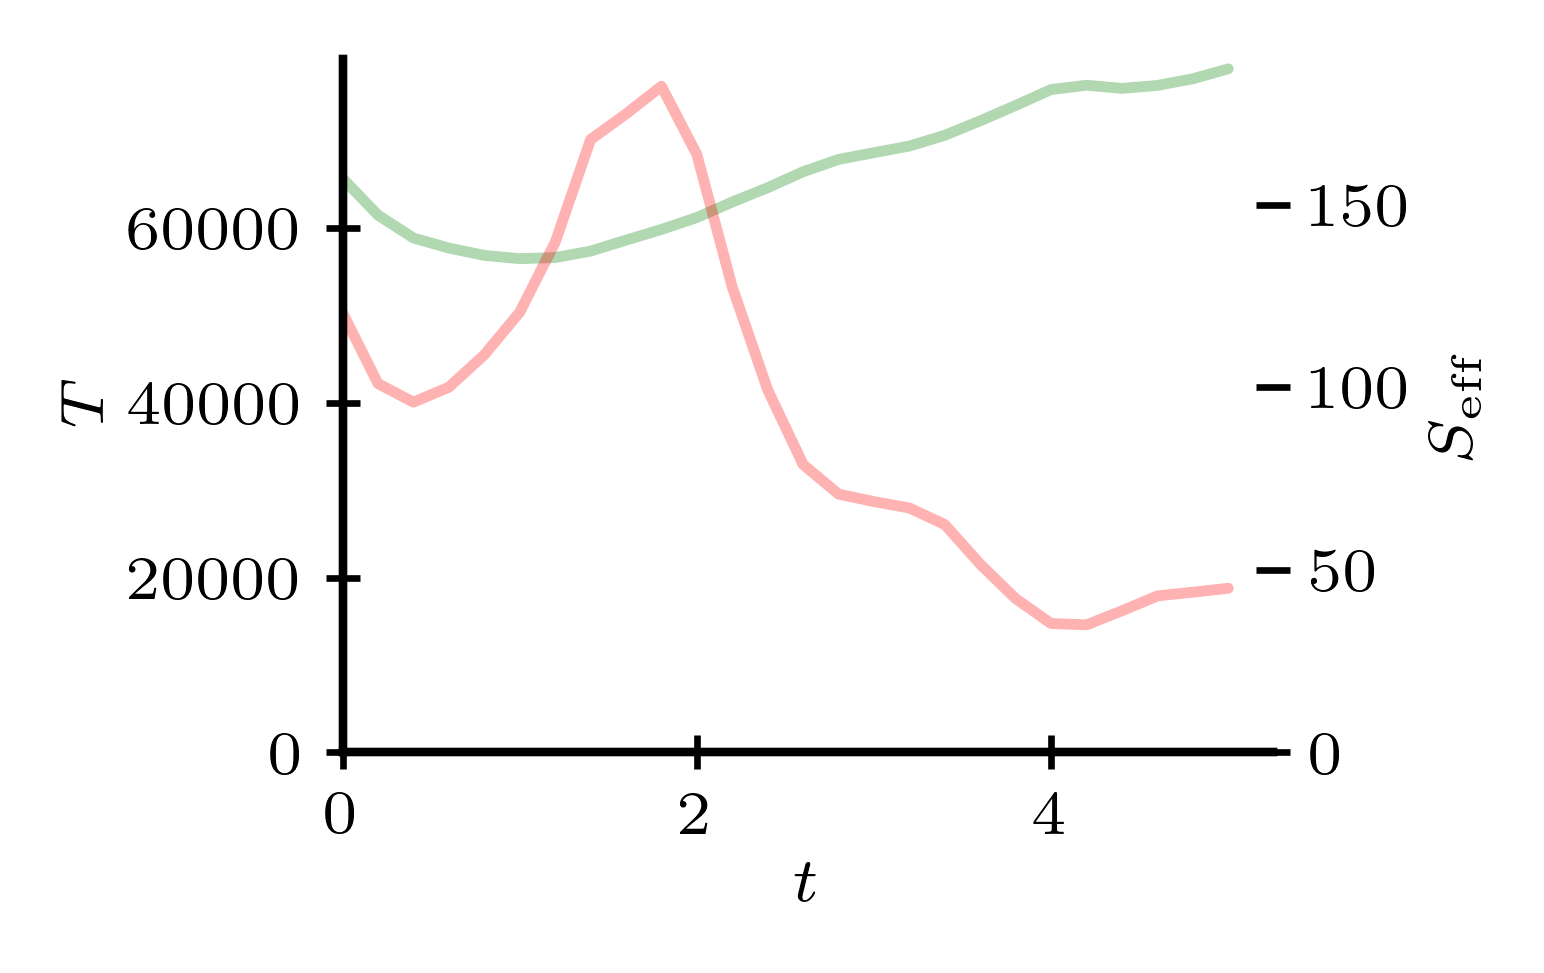

In [130]:
fig, ax1 = plt.subplots(figsize=(2, 1.5))

T = np.zeros(len(t))
Seff = np.zeros(len(t))
cmaxes = np.zeros(len(t))
for i, time in enumerate(t):
    T[i] = np.mean(c_t[i].sum(axis=0))
    Seff[i] = lib.get_average_simpsons_diversity(c_t[i])
    cmaxes[i] = np.nanmax(c_t[i])
    
ax1.plot(t, T, c='green', alpha=0.3)
ax1.set_xlim(0, None)
ax1.set_ylim(0, None)
# ax1.set_yscale('log')
ax1.set_xlabel(r"$t$")
ax1.set_ylabel(r"$T$")

# ax1.plot(t, cmaxes)

ax2 = ax1.twinx()
ax2.plot(t, Seff, c='red', alpha=0.3)
# ax2.set_yscale('log')
ax2.set_ylim(0, None)
ax2.set_ylabel(r"$S_{\mathrm{eff}}$")
ax2.tick_params(axis='y');

# Two point inequality 

In [100]:
from scipy import integrate
from scipy.special import kv

def density_x_white_noise(x, M, D):
        
    Z = 2 * kv(0, M / (2 * D))
    
    return 1 / Z * np.exp(- M / (2 * D) * np.cosh(x))

def unnormalized_density_x_coloured_noise(x, M, D, lamb):
    
    return (1 + M/lamb * np.cosh(x)) * np.exp(- M /(2 * D) * (1 + M / (2 * lamb) * np.cosh(x)) * np.cosh(x))

def partition_function_x_coloured_noise(M, D, lamb, x_range=200):
    
    Z = integrate.quad(unnormalized_density_x_coloured_noise, -x_range, x_range, args=(M, D, lamb))[0]
    
    return Z

def density_x_coloured_noise(x, M, D, lamb):
    
    Z = partition_function_x_coloured_noise(M, D, lamb)
    
    return 1 /Z * unnormalized_density_x_coloured_noise(x, M, D, lamb) 

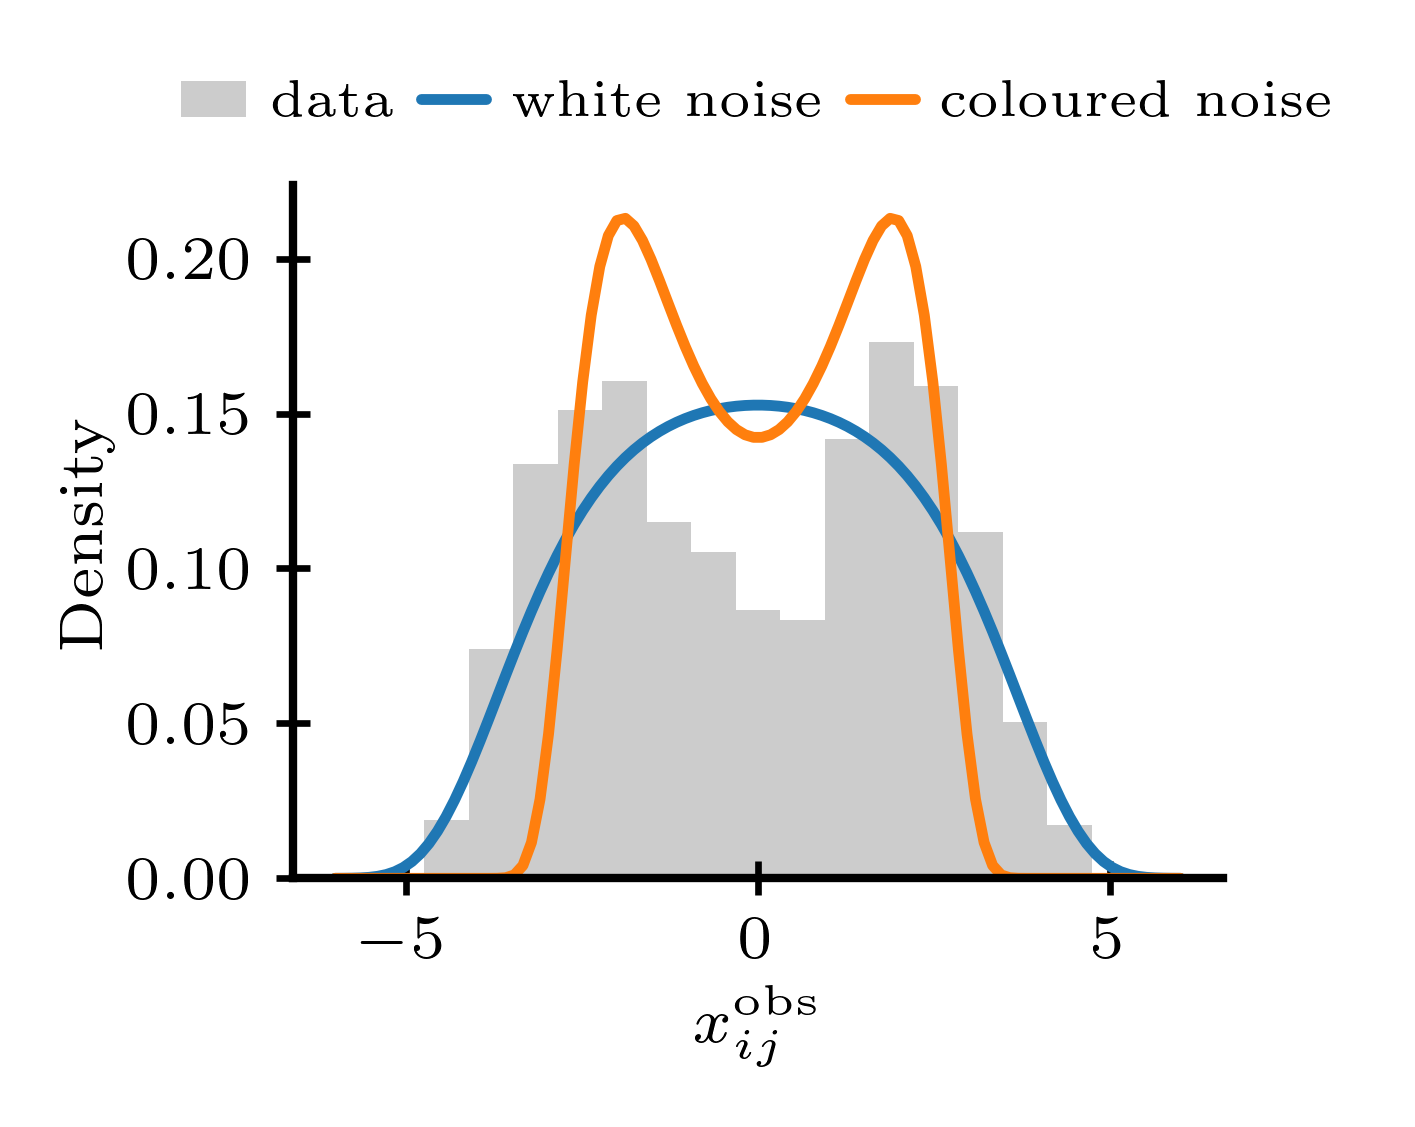

In [123]:
fig, ax = plt.subplots(figsize=(2, 1.5))
x_bound = 6
bins = np.linspace(-x_bound, x_bound, 20)
ax.hist(lib.get_empirical_log_ratios(c[:, 0], c[:, 1], threshold=10, base=np.exp(1)), density=True, bins=bins, alpha=0.2, color='black', label='data')

xs = np.linspace(-x_bound, x_bound, 100)

M = 0.1
D = 1
lamb = 0.1

ax.plot(xs, density_x_white_noise(xs, M=M, D=D), label='white noise')
ax.plot(xs, density_x_coloured_noise(xs, M=M, D=D, lamb=lamb), label='coloured noise')

ax.set_xlabel(r'$x^{\mathrm{obs}}_{ij}$')
ax.set_ylabel('Density')
ax.legend(loc="upper center",bbox_to_anchor=(0.5, 1.2), ncol=3, frameon=False);